In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Setup
np.random.seed(42)
sns.set_theme(style="whitegrid")

# ============================================================
# POINT 1 — RFM FEATURE TABLE BUILT FROM RAW TRANSACTIONS
# ============================================================

# Load dataset using relative repo path
data_path = "../../../../01-ml-project/retail_transactions_segmentation.csv"

print("Dataset loaded from:", data_path)

df_raw = pd.read_csv(data_path)

# Data cleaning
df_raw["transaction_date"] = pd.to_datetime(df_raw["transaction_date"], errors="coerce")
df = df_raw.dropna(subset=["customer_id", "transaction_date", "amount"]).copy()
df = df[df["amount"] > 0].copy()

# RFM Calculation & Explicit Decisions
reference_date = df["transaction_date"].max() + dt.timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    last_date=("transaction_date", "max"),
    Frequency=("transaction_date", "count"),
    Monetary=("amount", "sum")  # Explicit Decision: Total spend per customer
).reset_index()

rfm["Recency"] = (reference_date - rfm["last_date"]).dt.days
rfm = rfm[["customer_id", "Recency", "Frequency", "Monetary"]]

print(f"\nExplicit Choice - Reference Date Used for Recency: {reference_date.date()}")
print("Explicit Choice - Monetary Definition: Total spend per customer")
print("\n--- RFM Table Head ---")
print(rfm.head())
print(f"\nRFM Table Shape: {rfm.shape} (300 customers)")

Dataset loaded from: ../../../../01-ml-project/retail_transactions_segmentation.csv

Explicit Choice - Reference Date Used for Recency: 2024-12-31
Explicit Choice - Monetary Definition: Total spend per customer

--- RFM Table Head ---
   customer_id  Recency  Frequency  Monetary
0         5001        2         16   5172.45
1         5002       23         18   6158.98
2         5003       37          3    654.12
3         5004        5         35  31050.88
4         5005       26         16   5700.91

RFM Table Shape: (300, 4) (300 customers)


In [2]:
# ============================================================
# POINT 2 — FEATURES SCALED BEFORE CLUSTERING
# ============================================================

features = ["Recency", "Frequency", "Monetary"]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[features])

print("\n--- Scaled RFM Features Head ---")
print(pd.DataFrame(rfm_scaled, columns=features).head())


--- Scaled RFM Features Head ---
    Recency  Frequency  Monetary
0 -0.772792   0.356692 -0.113196
1 -0.464634   0.544920 -0.010898
2 -0.259195  -0.866790 -0.581723
3 -0.728770   2.144859  2.570262
4 -0.420611   0.356692 -0.058397


c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

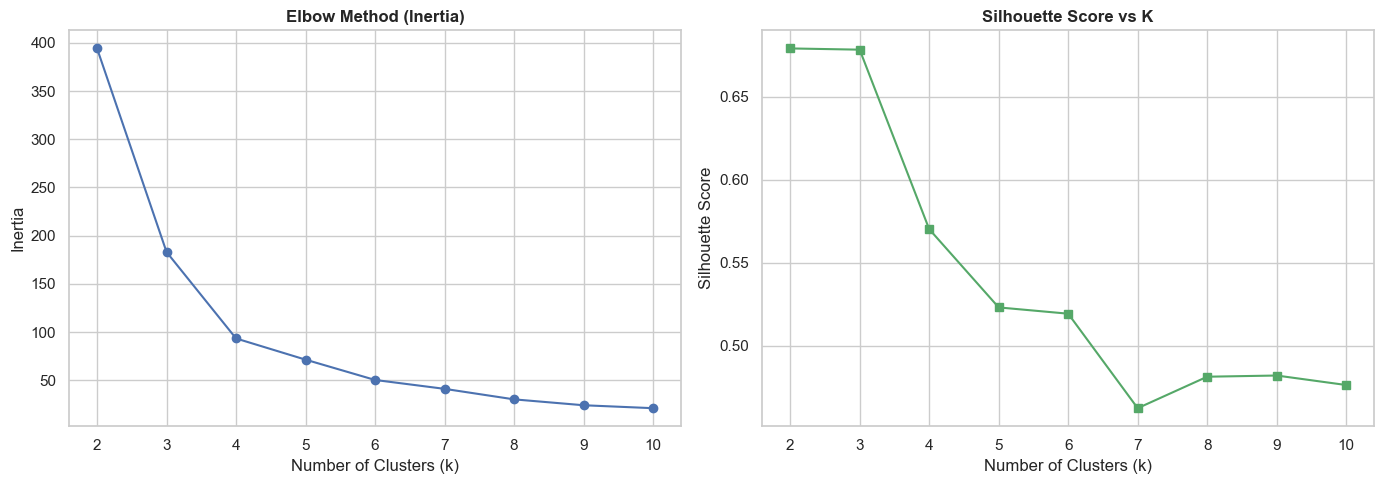


Selected K: 2
Best Silhouette Score: 0.6789


In [3]:
# ============================================================
# POINT 3 — CHOICE OF K JUSTIFIED WITH EVIDENCE
# ============================================================

inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, labels))

# Plotting Elbow and Silhouette
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertia, marker="o", color="b")
ax1.set_title("Elbow Method (Inertia)", fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_xticks(list(k_range))

ax2.plot(list(k_range), silhouette_scores, marker="s", color="g")
ax2.set_title("Silhouette Score vs K", fontweight="bold")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_xticks(list(k_range))

plt.tight_layout()
plt.show()

best_index = np.argmax(silhouette_scores)
chosen_k = list(k_range)[best_index]

print(f"\nSelected K: {chosen_k}")
print(f"Best Silhouette Score: {round(silhouette_scores[best_index], 4)}")

In [4]:
# ============================================================
# POINT 4 — K-MEANS FITTED WITH CHOSEN K
# ============================================================

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("\n--- Number of Customers Per Cluster ---")
print(rfm["Cluster"].value_counts().sort_index())


--- Number of Customers Per Cluster ---
Cluster
0     40
1    260
Name: count, dtype: int64


c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


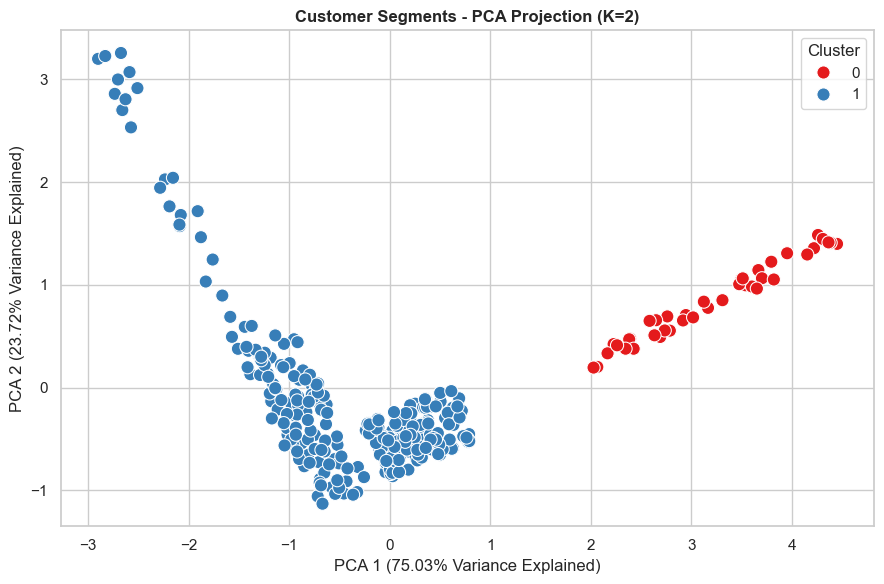

In [5]:
# ============================================================
# POINT 5 — PCA VISUALIZATION OF CLUSTERS
# ============================================================

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(rfm_scaled)

rfm["PCA1"] = pca_result[:, 0]
rfm["PCA2"] = pca_result[:, 1]

plt.figure(figsize=(9, 6))
sns.scatterplot(data=rfm, x="PCA1", y="PCA2", hue="Cluster", palette="Set1", s=90)
plt.title(f"Customer Segments - PCA Projection (K={chosen_k})", fontweight="bold")
plt.xlabel(f"PCA 1 ({round(pca.explained_variance_ratio_[0]*100, 2)}% Variance Explained)")
plt.ylabel(f"PCA 2 ({round(pca.explained_variance_ratio_[1]*100, 2)}% Variance Explained)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# POINT 6 — NAMED PERSONAS GROUNDED IN NUMBERS
# ============================================================

cluster_summary = rfm.groupby("Cluster")[features].mean().reset_index()

profile = cluster_summary.set_index("Cluster")
vip_cluster = int(((-profile["Recency"]).rank(pct=True) + profile["Frequency"].rank(pct=True) + profile["Monetary"].rank(pct=True)).idxmax())
dormant_cluster = int((profile["Recency"].rank(pct=True) + (-profile["Frequency"]).rank(pct=True) + (-profile["Monetary"]).rank(pct=True)).idxmax())
remaining = [int(c) for c in profile.index if int(c) not in {vip_cluster, dormant_cluster}]

persona_map = {vip_cluster: "VIP / Champions", dormant_cluster: "Dormant / Lost"}
if remaining:
    recent_cluster = int(profile.loc[remaining, "Recency"].idxmin())
    persona_map[recent_cluster] = "Recent / Occasional Buyers"
for c in remaining:
    if c not in persona_map:
        persona_map[c] = "At-Risk Customers"

rfm["Persona"] = rfm["Cluster"].map(persona_map)

final_persona_summary = cluster_summary.copy()
final_persona_summary["Persona"] = final_persona_summary["Cluster"].map(persona_map)
print("\n--- Cluster RFM Averages & Assigned Personas ---")
print(final_persona_summary[["Cluster", "Persona", "Recency", "Frequency", "Monetary"]].round(2))

print("\n--- Persona Descriptions & Business Recommendations ---")
for cluster in sorted(rfm["Cluster"].unique()):
    row = cluster_summary[cluster_summary["Cluster"] == cluster].iloc[0]
    persona = persona_map[cluster]
    print(f"\nCluster {cluster} — Persona: {persona}")
    if persona == "VIP / Champions":
        print(f"• Profile: Highly active and loyal customers with low recency ({row['Recency']:.1f} days), high frequency ({row['Frequency']:.1f}), and top spending (${row['Monetary']:.2f}).")
        print("• Action: Focus on retention with VIP rewards, exclusive product previews, and premium customer support.")
    elif persona == "Dormant / Lost":
        print(f"• Profile: Churned or inactive customers with high recency ({row['Recency']:.1f} days), low frequency ({row['Frequency']:.1f}), and low total spend (${row['Monetary']:.2f}).")
        print("• Action: Deploy targeted re-activation email campaigns featuring personalized discount incentives.")
    elif persona == "Recent / Occasional Buyers":
        print(f"• Profile: Recent shoppers ({row['Recency']:.1f} days) with moderate purchase counts ({row['Frequency']:.1f}) and spending (${row['Monetary']:.2f}).")
        print("• Action: Encourage repeat buying through post-purchase recommendations and bundle discounts.")
    else:
        print(f"• Profile: Customers showing declining engagement with increasing recency ({row['Recency']:.1f} days) and moderate spend (${row['Monetary']:.2f}).")
        print("• Action: Re-engage with proactive surveys, tailored offers, and loyalty points before they turn completely dormant.")

# Validation Checks
assert len(df_raw) == 3663
assert len(rfm) == 300
assert rfm["customer_id"].is_unique
assert rfm["Persona"].notna().all()

print("\n==========================================")
print("ALL SUBMISSION REQUIREMENTS & VALIDATION CHECKS PASSED!")
print("==========================================")


--- Cluster RFM Averages & Assigned Personas ---
   Cluster          Persona  Recency  Frequency  Monetary
0        0  VIP / Champions     8.40       35.0  29683.61
1        1   Dormant / Lost    61.78        8.7   2661.07

--- Persona Descriptions & Business Recommendations ---

Cluster 0 — Persona: VIP / Champions
• Profile: Highly active and loyal customers with low recency (8.4 days), high frequency (35.0), and top spending ($29683.61).
• Action: Focus on retention with VIP rewards, exclusive product previews, and premium customer support.

Cluster 1 — Persona: Dormant / Lost
• Profile: Churned or inactive customers with high recency (61.8 days), low frequency (8.7), and low total spend ($2661.07).
• Action: Deploy targeted re-activation email campaigns featuring personalized discount incentives.

ALL SUBMISSION REQUIREMENTS & VALIDATION CHECKS PASSED!
